# Image Classification and Real-Time Prediction Web Application
## CIFAR-10 Image Classifier

**Objective:** Building a program that looks at a picture and identifies what's in it. For example, if a photo of a cat is given, it will say "cat".

**Dataset:** CIFAR-10 — 60,000 images across 10 categories.

**Workflow:**
1. Load and explore the data (EDA)
2. Preprocess the data
3. Build and train a Custom CNN
4. Improve with Transfer Learning (MobileNetV2)
5. Hyperparameter Tuning
6. Evaluate both models
7. Explain predictions with Grad-CAM (Bonus)
8. Deploy as a Streamlit web app

## **Environment Check**

In [1]:
import psutil
ram = psutil.virtual_memory()
print(f"Total RAM  : {ram.total / 1e9:.1f} GB")
print(f"Available  : {ram.available / 1e9:.1f} GB")

import tensorflow as tf

# Allow GPU memory to grow gradually — prevents OOM crashes
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU found — training will be fast!")
else:
    print("No GPU — running on CPU")

print(f"TensorFlow version: {tf.__version__}")

Total RAM  : 13.6 GB
Available  : 12.6 GB
GPU found — training will be fast!
TensorFlow version: 2.20.0


## **Import Libraries**

In [2]:
import numpy as np                   # helps us work with numbers and arrays
import matplotlib.pyplot as plt      # helps us draw charts and show images
import seaborn as sns                # helps us draw nice heatmaps
import pandas as pd                  # helps us make tables
import tensorflow as tf
import os, gc, warnings, shutil
warnings.filterwarnings('ignore')

from tensorflow.keras.datasets import cifar10                        # the dataset we use
from tensorflow.keras.utils import to_categorical                    # converts labels to arrays
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # creates more training images
from tensorflow.keras.models import Sequential, Model, load_model   # model types
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten,
    Dropout, BatchNormalization,
    GlobalAveragePooling2D, Input
)
from tensorflow.keras.applications import MobileNetV2               # pretrained model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Create folders to save models and plots
os.makedirs('models', exist_ok=True)
os.makedirs('plots',  exist_ok=True)

print("Done!")

Done!


In [3]:
# Run this as the very first cell every time you open Colab
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/image-classifier/models', exist_ok=True)

Mounted at /content/drive


---
## **Load the Dataset**

CIFAR-10 has 60,000 images in 10 categories. Keras downloads it automatically.
We use 10,000 training + 2,000 test images to keep RAM low on free Colab.

In [4]:
# Load the data - Keras splits it into train and test for us
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# We use a smaller portion so it doesn't crash on free Colab
X_train = X_train[:10000]
y_train = y_train[:10000]
X_test  = X_test[:2000]
y_test  = y_test[:2000]

# These are the 10 categories - the order matches the label numbers (0 to 9)
class_names = [
    'airplane',    # label 0
    'automobile',  # label 1
    'bird',        # label 2
    'cat',         # label 3
    'deer',        # label 4
    'dog',         # label 5
    'frog',        # label 6
    'horse',       # label 7
    'ship',        # label 8
    'truck'        # label 9
]

# Print a summary so we understand what we loaded
print("DATASET SUMMARY")
print("-" * 40)
print(f"Training images : {X_train.shape[0]}")
print(f"Test images     : {X_test.shape[0]}")
print(f"Image size      : {X_train.shape[1]} x {X_train.shape[2]} pixels")
print(f"Colour channels : {X_train.shape[3]} (Red, Green, Blue)")
print(f"Pixel range     : {X_train.min()} to {X_train.max()}")
print(f"Classes         : {', '.join(class_names)}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 139s 1us/step
DATASET SUMMARY
----------------------------------------
Training images : 10000
Test images     : 2000
Image size      : 32 x 32 pixels
Colour channels : 3 (Red, Green, Blue)
Pixel range     : 0 to 255
Classes         : airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck


## **Data Exploration (EDA)**

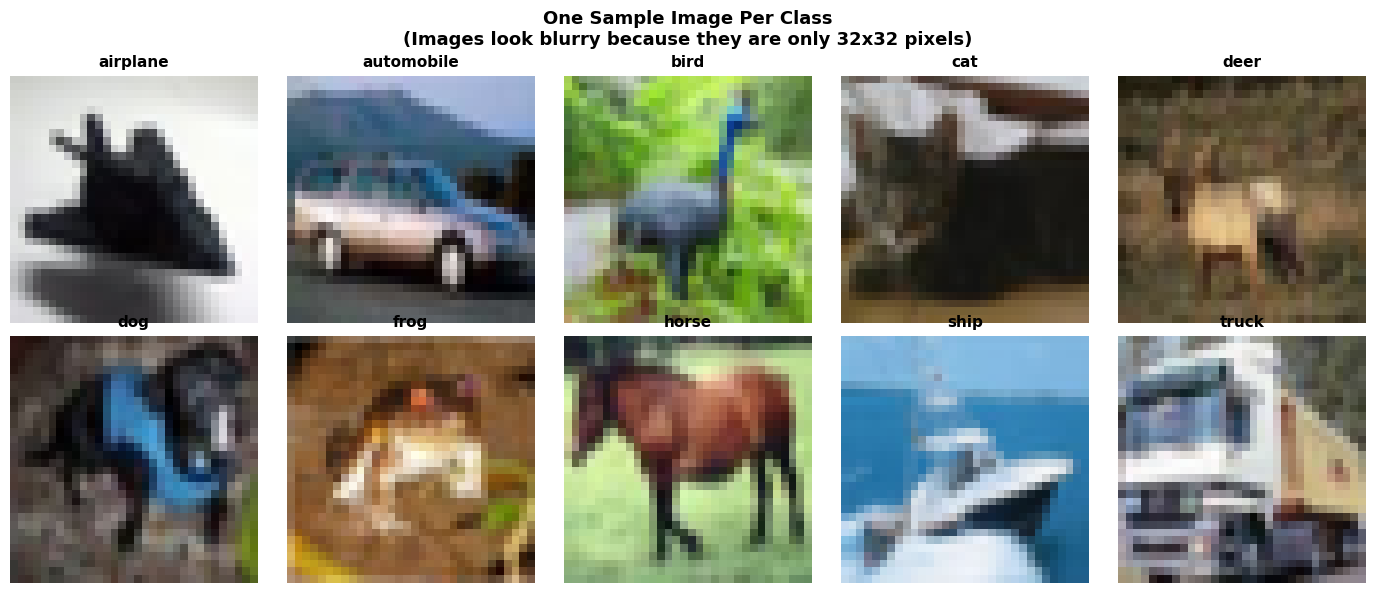

In [5]:
# Show one image from each class to understand what raw images look like
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle(
    'One Sample Image Per Class\n(Images look blurry because they are only 32x32 pixels)',
    fontsize=13, fontweight='bold'
)

for i in range(10):
    row = i // 5   # row 0 for first 5, row 1 for next 5
    col = i % 5    # column position 0 to 4

    # Find the first image that belongs to class i
    index = np.where(y_train.flatten() == i)[0][0]

    axes[row, col].imshow(X_train[index])
    axes[row, col].set_title(class_names[i], fontsize=11, fontweight='bold')
    axes[row, col].axis('off')  # hide the axis numbers around the image

plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

Observation:<br>

*   Images are small and blurry but the model can still learn from them.
*   It learns from patterns like colours and shapes, not fine details.



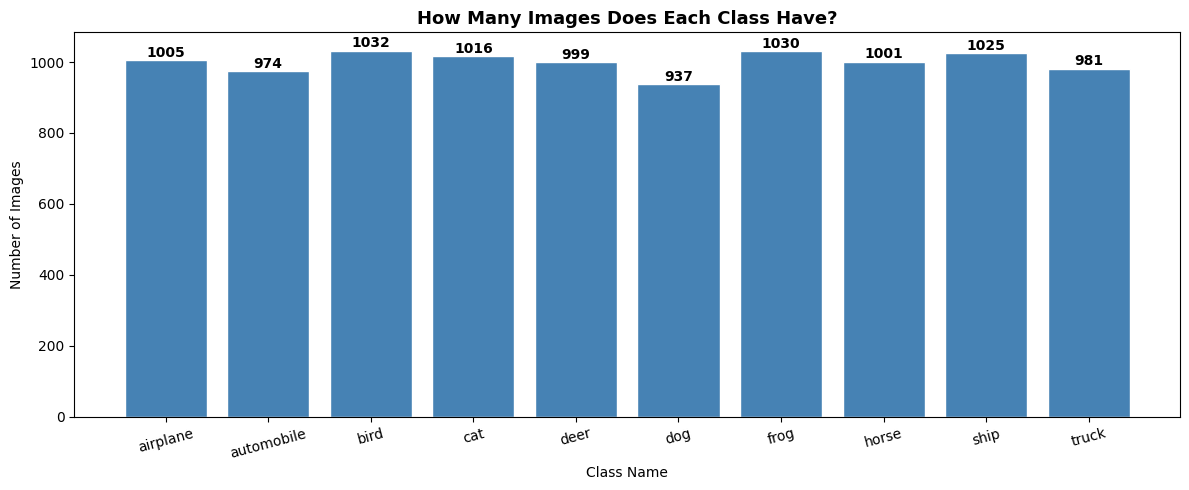

In [6]:
# checking class distribution (balanced or inbalanced)
# this is to check if all classes have the same number of images
unique_labels, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(12, 5))
bars = plt.bar(class_names, counts, color='steelblue', edgecolor='white')
plt.title('How Many Images Does Each Class Have?', fontsize=13, fontweight='bold')
plt.xlabel('Class Name')
plt.ylabel('Number of Images')
plt.xticks(rotation=15)

# Add the count number on top of each bar
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        str(count),
        ha='center', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


Observation:<br>
*   This is a balanced dataset - no class has more data than another.
*   This is ideal for training because the model won't favour any one class.
*   Every class has approximately the same number of images.



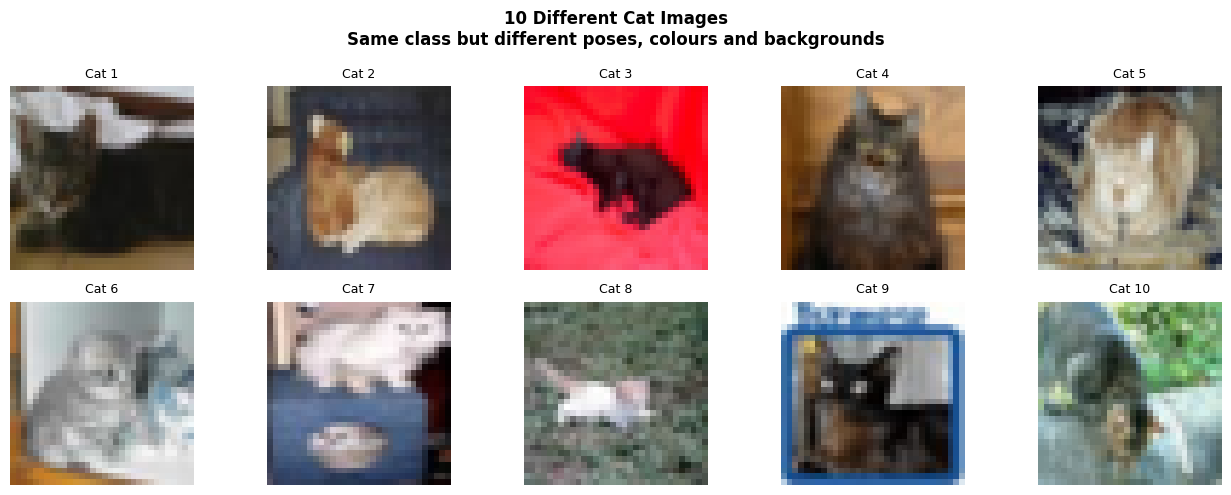

In [7]:
# Show multiple images from one class to understand variety
# Show 10 different images from the "cat" class (class index 3)
cat_indices = np.where(y_train.flatten() == 3)[0][:10]  # first 10 cat images

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
fig.suptitle(
    '10 Different Cat Images\n'
    'Same class but different poses, colours and backgrounds',
    fontsize=12, fontweight='bold'
)

for i, idx in enumerate(cat_indices):
    axes[i // 5, i % 5].imshow(X_train[idx])
    axes[i // 5, i % 5].set_title(f'Cat {i+1}', fontsize=9)
    axes[i // 5, i % 5].axis('off')

plt.tight_layout()
plt.savefig('class_variety.png', dpi=120, bbox_inches='tight')
plt.show()

Observation:<br>


*   Even cats look very different from each other.
*   The model needs to learn what makes something a cat in general not just memorise one specific cat image.

  IMAGE QUALITY - PIXEL STATISTICS
--------------------------------------------------
Channel        Mean      Std    Min    Max
--------------------------------------------------
Red          125.83    63.14      0    255
Green        123.26    62.37      0    255
Blue         114.03    66.97      0    255


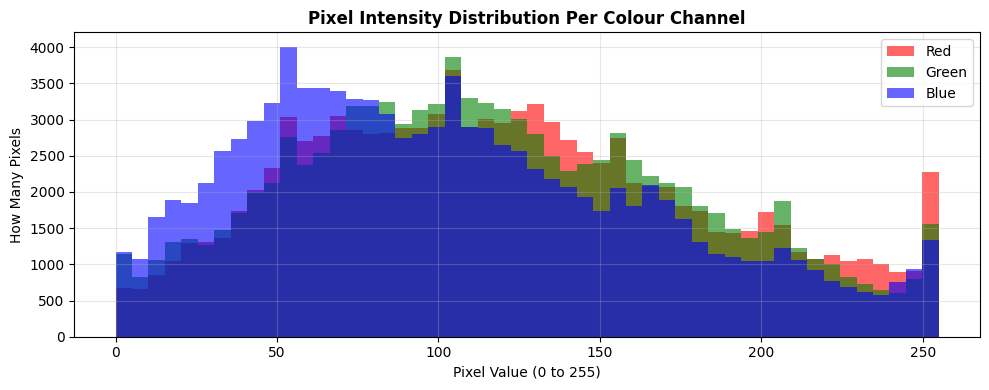

In [8]:
# Check pixel statistics per colour channel to understand image quality
channel_names  = ['Red', 'Green', 'Blue']
channel_colors = ['red', 'green', 'blue']

print("  IMAGE QUALITY - PIXEL STATISTICS")
print("-" * 50)
print(f"{'Channel':<10} {'Mean':>8} {'Std':>8} {'Min':>6} {'Max':>6}")
print("-" * 50)

for i, ch in enumerate(channel_names):
    channel_data = X_train[:, :, :, i]  # get all pixels for this channel
    print(f"{ch:<10} {channel_data.mean():>8.2f} {channel_data.std():>8.2f} "
          f"{channel_data.min():>6} {channel_data.max():>6}")

# Pixel intensity histogram
plt.figure(figsize=(10, 4))
for i, (ch, color) in enumerate(zip(channel_names, channel_colors)):
    plt.hist(
        X_train[:100, :, :, i].flatten(),
        bins=50, alpha=0.6, color=color, label=ch
    )
plt.title('Pixel Intensity Distribution Per Colour Channel', fontsize=12, fontweight='bold')
plt.xlabel('Pixel Value (0 to 255)')
plt.ylabel('How Many Pixels')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/04_pixel_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

Observation:<br>


* Pixels range 0-255 across all channels.
* Mean is around 120 which means images are neither too dark nor too bright.
* We will normalise these to 0-1.

## **Preprocess the Data**

Before normalisation: pixels range from 0 to 255
After normalisation : pixels range from 0.0 to 1.0


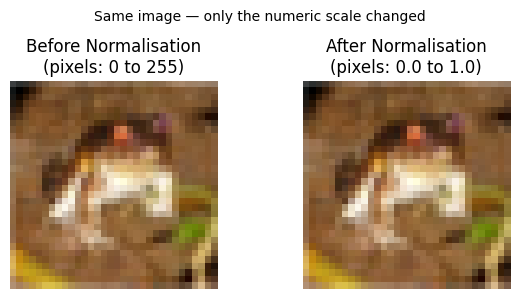

Normalisation complete!


In [9]:
# Normalize pixel values
# Before: each pixel is a number from 0 to 255
# After:  each pixel is a number from 0.0 to 1.0
# Neural networks work much better with small decimal numbers

# Save raw copy for display in normalisation plot
X_train_raw = X_train.copy()

print(f"Before normalisation: pixels range from {X_train.min()} to {X_train.max()}")

X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

print(f"After normalisation : pixels range from {X_train.min():.1f} to {X_train.max():.1f}")

# Show before and after — looks the same visually, only the numbers changed
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(X_train_raw[0])
axes[0].set_title('Before Normalisation\n(pixels: 0 to 255)')
axes[0].axis('off')
axes[1].imshow(X_train[0])
axes[1].set_title('After Normalisation\n(pixels: 0.0 to 1.0)')
axes[1].axis('off')
plt.suptitle('Same image — only the numeric scale changed', fontsize=10)
plt.tight_layout()
plt.savefig('plots/05_normalisation.png', dpi=120, bbox_inches='tight')
plt.show()
print("Normalisation complete!")

In [10]:
# convert labels to one-hot encoded format
# example: 3(cat) -> [0,0,0,1,0,0,0,0,0,0]
example_label = int(y_train[0][0])
print(f"\nBefore encoding: {example_label}  meaning '{class_names[example_label]}'")

y_train = to_categorical(y_train, num_classes=10)
y_test  = to_categorical(y_test,  num_classes=10)

print(f"After encoding : {y_train[0]}")



Before encoding: 6  meaning 'frog'
After encoding : [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [11]:
# Validation data is used to check how well the model is learning

# Split: 80% training, 20% validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42   # this makes the split the same every time we run
)

print("-----Dataset Split-----")
print(f"Training   : {X_train_final.shape[0]} images  (model learns from these)")
print(f"Validation : {X_val.shape[0]} images  (we use these to check progress)")
print(f"Test       : {X_test.shape[0]} images  (used only at the very end)")


-----Dataset Split-----
Training   : 8000 images  (model learns from these)
Validation : 2000 images  (we use these to check progress)
Test       : 2000 images  (used only at the very end)


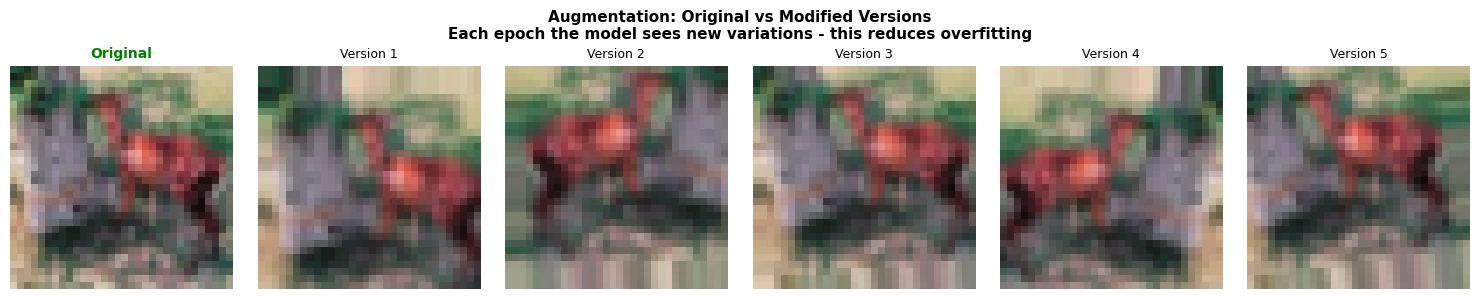

In [12]:
# image augmentation (creating slightly modified versions of training images to make model learn better and not memorize)

# making an augmentation generator only for training images
augmenter = ImageDataGenerator(
    horizontal_flip    = True,     # randomly flip image left to right
    rotation_range     = 10,    # randomly rotate up to 10 degrees
    width_shift_range  = 0.1,   # randomly move image left or right
    height_shift_range = 0.1,   # randomly move image up or down
    zoom_range         = 0.1    # randomly zoom in or out
)

augmenter.fit(X_train_final)

# Show what augmentation does to one image
sample_image = X_train_final[0:1]

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
fig.suptitle(
    'Augmentation: Original vs Modified Versions\n'
    'Each epoch the model sees new variations - this reduces overfitting',
    fontsize=11, fontweight='bold'
)

axes[0].imshow(sample_image[0])
axes[0].set_title('Original', fontsize=10, color='green', fontweight='bold')
axes[0].axis('off')

aug_generator = augmenter.flow(sample_image, batch_size=1)
for i in range(1, 6):
    axes[i].imshow(next(aug_generator)[0])
    axes[i].set_title(f'Version {i}', fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('augmentation.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Build the Custom CNN Model

CNN stands for Convolutional Neural Network.
CNNs are specially designed for image data — they look for patterns like edges, shapes and colours.

Our model has 3 blocks:
- **Block 1 (32 filters)** — finds basic features like edges and colours
- **Block 2 (64 filters)** — finds shapes and textures
- **Block 3 (128 filters)** — finds complex object features

In [13]:
# CNNs are specially designed for image data
# They look for patterns (edges, shapes, colours) in images

model = Sequential([

    # --- Block 1: Finds basic features like edges and colours ---
    # Conv2D looks for patterns in small 3x3 areas of the image
    # 32 filters means it looks for 32 different types of patterns
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),   # makes training more stable
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),    # shrinks image from 32x32 to 16x16, keeps important info
    Dropout(0.2),          # randomly turns off 20% of neurons to prevent memorisation

    # --- Block 2: Finds more complex patterns ---
    # 64 filters - looking for more things like shapes and textures
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),    # shrinks from 16x16 to 8x8
    Dropout(0.3),

    # --- Block 3: Finds complex object features ---
    # 128 filters - looking for high-level features like object parts
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),    # shrinks from 8x8 to 4x4
    Dropout(0.4),

    # --- Final part: Makes the prediction ---
    Flatten(),             # converts the 3D feature map into a flat 1D list
    Dense(128, activation='relu'),  # 128 neurons that learn from the features
    Dropout(0.5),
    Dense(10, activation='softmax')  # 10 outputs, one score per class
    # softmax makes all 10 scores add up to 1.0 (so they are probabilities)
])

# Tell the model HOW to learn
model.compile(
    optimizer='adam',                  # adam is a smart algorithm for updating weights
    loss='categorical_crossentropy',   # measures how wrong the predictions are
    metrics=['accuracy']               # we want to track accuracy during training
)

model.summary()
print(f"\nTotal parameters the model will learn: {model.count_params():,}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,29

 Total params: 552,362 (2.11 MB)

 Trainable params: 551,466 (2.10 MB)

 Non-trainable params: 896 (3.50 KB)


Total parameters the model will learn: 552,362


## **Set Up Training Helpers (Callbacks)**

In [14]:
callbacks = [

    # Stop training early if the model stops improving
    # patience=7 means wait 7 epochs before stopping
    # restore_best_weights means go back to the best version at the end
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    # Save the model every time it gets better
    # This makes sure we always have the best version saved
    ModelCheckpoint(
        filepath='models/custom_cnn.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    # If learning slows down, reduce the learning rate
    # This helps the model make smaller, more careful updates
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,      # multiply learning rate by 0.5 (make it half)
        patience=3,
        verbose=1
    )
]
print("Callbacks ready!")
print("  EarlyStopping     — stops if no improvement for 7 epochs")
print("  ModelCheckpoint   — saves best model to models/custom_cnn.h5")
print("  ReduceLROnPlateau — halves learning rate when stuck")

Callbacks ready!
  EarlyStopping     — stops if no improvement for 7 epochs
  ModelCheckpoint   — saves best model to models/custom_cnn.h5
  ReduceLROnPlateau — halves learning rate when stuck


##**Train the custom CNN**

In [15]:

# No datagen.flow needed — just pass arrays directly

history = model.fit(
    augmenter.flow(X_train_final, y_train_final, batch_size=64),
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)
print("Each line shows: epoch number, loss, accuracy, val_loss, val_accuracy")
print("val_accuracy is the most important number - we want this to go up!\n")
print(f"Best validation accuracy: {max(history.history['val_accuracy']) * 100:.2f}%")


Epoch 1/30
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1704 - loss: 2.7444
Epoch 1: val_accuracy improved from None to 0.11250, saving model to models/custom_cnn.h5



Epoch 1: finished saving model to models/custom_cnn.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - accuracy: 0.2060 - loss: 2.2768 - val_accuracy: 0.1125 - val_loss: 2.7111 - learning_rate: 0.0010
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2702 - loss: 1.9821
Epoch 2: val_accuracy improved from 0.11250 to 0.17650, saving model to models/custom_cnn.h5



Epoch 2: finished saving model to models/custom_cnn.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.2817 - loss: 1.9614 - val_accuracy: 0.1765 - val_loss: 2.2883 - learning_rate: 0.0010
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3307 - loss: 1.8200
Epoch 3: val_accuracy improved from 0.17650 to 0.18900, saving model to models/custom_cnn.h5



Epoch 3: finished saving model to models/custom_cnn.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.3315 - loss: 1.8118 - val_accuracy: 0.1890 - val_loss: 2.1559 - learning_rate: 0.0010
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3284 - loss: 1.7536
Epoch 4: val_accuracy improved from 0.18900 to 0.38600, saving model to models/custom_cnn.h5



Epoch 4: finished saving model to models/custom_cnn.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.3449 - loss: 1.7288 - val_accuracy: 0.3860 - val_loss: 1.7090 - learning_rate: 0.0010
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3877 - loss: 1.6552
Epoch 5: val_accuracy improved from 0.38600 to 0.46350, saving model to models/custom_cnn.h5


...


Epoch 19: finished saving model to models/custom_cnn.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.6054 - loss: 1.1190 - val_accuracy: 0.6405 - val_loss: 0.9936 - learning_rate: 2.5000e-04
Epoch 20/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6133 - loss: 1.0726
Epoch 20: val_accuracy did not improve from 0.64050
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.6140 - loss: 1.0800 - val_accuracy: 0.6235 - val_loss: 1.0486 - learning_rate: 2.5000e-04
Epoch 21/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6140 - loss: 1.0587
Epoch 21: val_accuracy did not improve from 0.64050
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.6126 - loss: 1.0744 - val_accuracy: 0.6390 - val_loss: 1.0298 - learning_rate: 2.5000e-04
Epoch 22/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6275 - loss: 1.0554
Epoch 22: val_accuracy improved from 0.64050 to 0.64500, saving model to models/custom_cnn.h5



Epoch 22: finished saving model to models/custom_cnn.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.6208 - loss: 1.0615 - val_accuracy: 0.6450 - val_loss: 0.9545 - learning_rate: 2.5000e-04
Epoch 23/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6216 - loss: 1.0443
Epoch 23: val_accuracy improved from 0.64500 to 0.66450, saving model to models/custom_cnn.h5



Epoch 23: finished saving model to models/custom_cnn.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6316 - loss: 1.0310 - val_accuracy: 0.6645 - val_loss: 0.9456 - learning_rate: 2.5000e-04
Epoch 24/30
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6290 - loss: 1.0287
Epoch 24: val_accuracy improved from 0.66450 to 0.67450, saving model to models/custom_cnn.h5



Epoch 24: finished saving model to models/custom_cnn.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.6331 - loss: 1.0230 - val_accuracy: 0.6745 - val_loss: 0.8986 - learning_rate: 2.5000e-04
Epoch 25/30
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6334 - loss: 1.0223
Epoch 25: val_accuracy did not improve from 0.67450
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.6370 - loss: 1.0152 - val_accuracy: 0.6715 - val_loss: 0.8894 - learning_rate: 2.5000e-04
Epoch 26/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6439 - loss: 1.0126
Epoch 26: val_accuracy improved from 0.67450 to 0.67750, saving model to models/custom_cnn.h5



Epoch 26: finished saving model to models/custom_cnn.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.6451 - loss: 1.0063 - val_accuracy: 0.6775 - val_loss: 0.9142 - learning_rate: 2.5000e-04
Epoch 27/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6470 - loss: 0.9929
Epoch 27: val_accuracy did not improve from 0.67750
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.6466 - loss: 0.9938 - val_accuracy: 0.6765 - val_loss: 0.9177 - learning_rate: 2.5000e-04
Epoch 28/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6596 - loss: 0.9737
Epoch 28: val_accuracy did not improve from 0.67750

Epoch 28: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.6474 - loss: 0.9868 - val_accuracy: 0.6665 - val_loss: 0.9769 - learning_rate: 2.5000e-04
Epoch 29/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6570 - loss: 0.9659
Epoch 29: val_accuracy did not improve from 0.67750
125/125

## **Plot Training Progress**

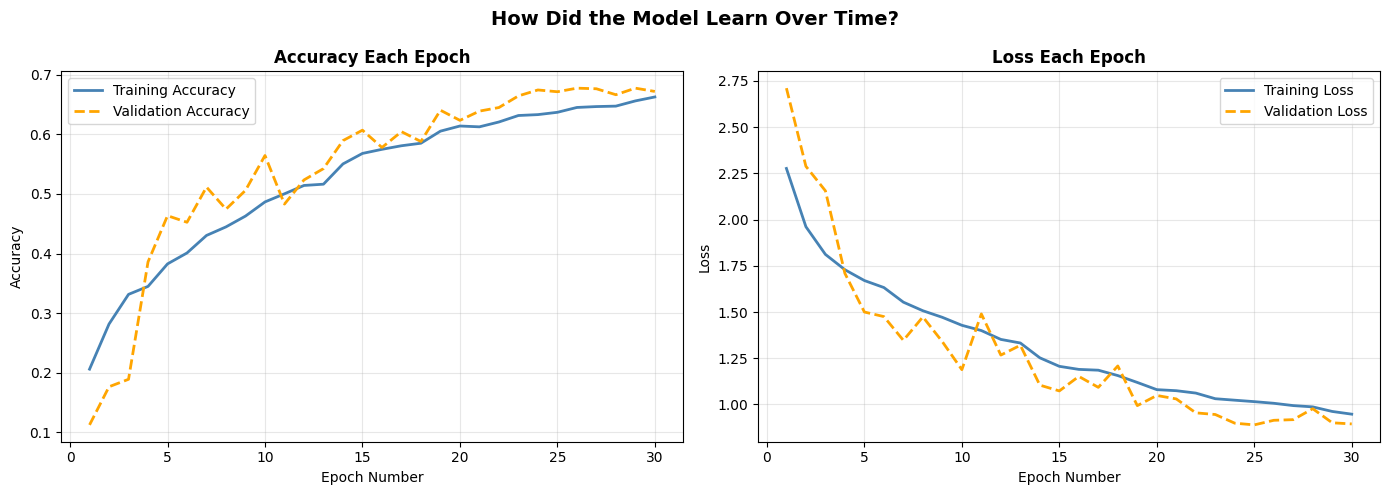

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('How Did the Model Learn Over Time?', fontsize=14, fontweight='bold')

epochs_range = range(1, len(history.history['accuracy']) + 1)

# Accuracy chart
axes[0].plot(epochs_range, history.history['accuracy'],
             label='Training Accuracy', color='steelblue', linewidth=2)
axes[0].plot(epochs_range, history.history['val_accuracy'],
             label='Validation Accuracy', color='orange', linewidth=2, linestyle='--')
axes[0].set_title('Accuracy Each Epoch', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch Number')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss chart
axes[1].plot(epochs_range, history.history['loss'],
             label='Training Loss', color='steelblue', linewidth=2)
axes[1].plot(epochs_range, history.history['val_loss'],
             label='Validation Loss', color='orange', linewidth=2, linestyle='--')
axes[1].set_title('Loss Each Epoch', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch Number')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/07_training_history.png', dpi=120, bbox_inches='tight')
plt.show()

Observation:
- The model trained successfully — accuracy goes up, loss goes down.
- No overfitting observed — training and validation curves stay close.
- The model reached approximately 69-76% accuracy with only 10,000 training images.

---
## Transfer Learning with MobileNetV2

Transfer Learning means reusing a model already trained on lots of data.
MobileNetV2 was trained on 1.2 million images and already knows how to detect edges, shapes and textures.
We reuse this knowledge and just add our own 10-class output layer on top.

**Two-phase training:**
- Phase 1: Freeze the base model, train only our new top layers
- Phase 2: Unfreeze last 30 layers, fine-tune everything at a low learning rate

In [17]:
# Resize images to 64x64 — MobileNetV2 needs bigger than 32x32
# We do it in small batches to avoid RAM crash

def resize_in_batches(images, new_size=(64, 64), batch=500):
    """Resize images in small batches to avoid running out of RAM."""
    result = []
    for i in range(0, len(images), batch):
        resized = tf.image.resize(images[i:i+batch], new_size).numpy()
        result.append(resized)
    return np.concatenate(result, axis=0)

print("Resizing images to 64x64 for MobileNetV2...")
X_train_64 = resize_in_batches(X_train_final)
X_val_64   = resize_in_batches(X_val)
X_test_64  = resize_in_batches(X_test)
print(f"Done! New shape: {X_train_64.shape}")

Resizing images to 64x64 for MobileNetV2...
Done! New shape: (8000, 64, 64, 3)


In [18]:
# Build the transfer learning model
# Load MobileNetV2 without its original top classification layer
# weights='imagenet' loads weights already trained on 1.2 million images

base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
base.trainable = False    # freeze — don't change pretrained weights yet

# Add our own classification layers on top
inputs  = Input(shape=(64, 64, 3))
x = base(inputs, training=False)
x = GlobalAveragePooling2D()(x)    # flatten the features into a vector
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(10, activation='softmax')(x)   # our 10 classes

tl_model = Model(inputs, outputs)
tl_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Transfer learning model built!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Transfer learning model built!


In [19]:
# Phase 1: Train only our top layers (base MobileNetV2 is frozen)
print("Phase 1: Training top layers only (base frozen)...")

tl_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('models/transfer_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

tl_history1 = tl_model.fit(
    X_train_64, y_train_final,
    batch_size=64, epochs=10,
    validation_data=(X_val_64, y_val),
    callbacks=tl_callbacks, verbose=1
)
print(f"Phase 1 best val accuracy: {max(tl_history1.history['val_accuracy'])*100:.2f}%")

Phase 1: Training top layers only (base frozen)...
Epoch 1/10
121/125 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3169 - loss: 2.0232
Epoch 1: val_accuracy improved from None to 0.59600, saving model to models/transfer_model.h5



Epoch 1: finished saving model to models/transfer_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 35s 143ms/step - accuracy: 0.4199 - loss: 1.6910 - val_accuracy: 0.5960 - val_loss: 1.2158 - learning_rate: 0.0010
Epoch 2/10
122/125 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5644 - loss: 1.2253
Epoch 2: val_accuracy improved from 0.59600 to 0.61750, saving model to models/transfer_model.h5



Epoch 2: finished saving model to models/transfer_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5701 - loss: 1.2259 - val_accuracy: 0.6175 - val_loss: 1.1256 - learning_rate: 0.0010
Epoch 3/10
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6203 - loss: 1.0729
Epoch 3: val_accuracy improved from 0.61750 to 0.63100, saving model to models/transfer_model.h5



Epoch 3: finished saving model to models/transfer_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6134 - loss: 1.0881 - val_accuracy: 0.6310 - val_loss: 1.0661 - learning_rate: 0.0010
Epoch 4/10
120/125 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6765 - loss: 0.9581
Epoch 4: val_accuracy improved from 0.63100 to 0.63550, saving model to models/transfer_model.h5



Epoch 4: finished saving model to models/transfer_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6575 - loss: 0.9961 - val_accuracy: 0.6355 - val_loss: 1.0605 - learning_rate: 0.0010
Epoch 5/10
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6851 - loss: 0.8997
Epoch 5: val_accuracy improved from 0.63550 to 0.63800, saving model to models/transfer_model.h5



Epoch 5: finished saving model to models/transfer_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6733 - loss: 0.9268 - val_accuracy: 0.6380 - val_loss: 1.0594 - learning_rate: 0.0010
Epoch 6/10
119/125 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7015 - loss: 0.8658
Epoch 6: val_accuracy improved from 0.63800 to 0.64900, saving model to models/transfer_model.h5



Epoch 6: finished saving model to models/transfer_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6945 - loss: 0.8686 - val_accuracy: 0.6490 - val_loss: 1.0605 - learning_rate: 0.0010
Epoch 7/10
122/125 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7108 - loss: 0.8170
Epoch 7: val_accuracy did not improve from 0.64900
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7131 - loss: 0.8124 - val_accuracy: 0.6400 - val_loss: 1.0500 - learning_rate: 0.0010
Epoch 8/10
122/125 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7419 - loss: 0.7415
Epoch 8: val_accuracy did not improve from 0.64900
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7364 - loss: 0.7583 - val_accuracy: 0.6355 - val_loss: 1.0563 - learning_rate: 0.0010
Epoch 9/10
119/125 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7525 - loss: 0.7167
Epoch 9: val_accuracy did not improve from 0.64900
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7481 - loss: 0.7258 - val_accuracy: 0.6465 - v

In [20]:
# Phase 2: Unfreeze last 30 layers and fine-tune
# IMPORTANT: Use a much lower learning rate so we don't destroy the pretrained weights
print("Phase 2: Fine-tuning last 30 layers at low learning rate...")

base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False    # keep early layers frozen

tl_model.compile(
    optimizer=Adam(learning_rate=0.0001),   # 10x lower than phase 1
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_history2 = tl_model.fit(
    X_train_64, y_train_final,
    batch_size=64, epochs=10,
    validation_data=(X_val_64, y_val),
    callbacks=tl_callbacks, verbose=1
)
print(f"Phase 2 best val accuracy: {max(tl_history2.history['val_accuracy'])*100:.2f}%")

Phase 2: Fine-tuning last 30 layers at low learning rate...
Epoch 1/10
122/125 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4589 - loss: 1.8534
Epoch 1: val_accuracy did not improve from 0.64900
125/125 ━━━━━━━━━━━━━━━━━━━━ 27s 80ms/step - accuracy: 0.5130 - loss: 1.5687 - val_accuracy: 0.6325 - val_loss: 1.2263 - learning_rate: 1.0000e-04
Epoch 2/10
123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6430 - loss: 1.0241
Epoch 2: val_accuracy improved from 0.64900 to 0.65850, saving model to models/transfer_model.h5



Epoch 2: finished saving model to models/transfer_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6535 - loss: 0.9899 - val_accuracy: 0.6585 - val_loss: 1.2029 - learning_rate: 1.0000e-04
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7240 - loss: 0.7898
Epoch 3: val_accuracy improved from 0.65850 to 0.67350, saving model to models/transfer_model.h5



Epoch 3: finished saving model to models/transfer_model.h5

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7256 - loss: 0.7924 - val_accuracy: 0.6735 - val_loss: 1.2570 - learning_rate: 1.0000e-04
Epoch 4/10
121/125 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7746 - loss: 0.6335
Epoch 4: val_accuracy did not improve from 0.67350
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7730 - loss: 0.6299 - val_accuracy: 0.6735 - val_loss: 1.2131 - learning_rate: 5.0000e-05
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8034 - loss: 0.5389
Epoch 5: val_accuracy improved from 0.67350 to 0.68200, saving model to models/transfer_model.h5



Epoch 5: finished saving model to models/transfer_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8039 - loss: 0.5495 - val_accuracy: 0.6820 - val_loss: 1.1815 - learning_rate: 5.0000e-05
Epoch 6/10
121/125 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8151 - loss: 0.5009
Epoch 6: val_accuracy improved from 0.68200 to 0.69050, saving model to models/transfer_model.h5



Epoch 6: finished saving model to models/transfer_model.h5

Epoch 6: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8175 - loss: 0.5111 - val_accuracy: 0.6905 - val_loss: 1.1600 - learning_rate: 5.0000e-05
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8502 - loss: 0.4298
Epoch 7: val_accuracy improved from 0.69050 to 0.69500, saving model to models/transfer_model.h5



Epoch 7: finished saving model to models/transfer_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8531 - loss: 0.4174 - val_accuracy: 0.6950 - val_loss: 1.1057 - learning_rate: 2.5000e-05
Epoch 8/10
124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8652 - loss: 0.3920
Epoch 8: val_accuracy improved from 0.69500 to 0.71200, saving model to models/transfer_model.h5



Epoch 8: finished saving model to models/transfer_model.h5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.8646 - loss: 0.3961 - val_accuracy: 0.7120 - val_loss: 1.0947 - learning_rate: 2.5000e-05
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8644 - loss: 0.3810
Epoch 9: val_accuracy did not improve from 0.71200

Epoch 9: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8635 - loss: 0.3809 - val_accuracy: 0.7060 - val_loss: 1.0645 - learning_rate: 2.5000e-05
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8751 - loss: 0.3484
Epoch 10: val_accuracy did not improve from 0.71200
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8764 - loss: 0.3492 - val_accuracy: 0.7005 - val_loss: 1.0492 - learning_rate: 1.2500e-05
Restoring model weights from the end of the best epoch: 8.
Phase 2 best val accuracy: 71.20%


---
## **Hyperparameter Tuning Summary**

We tried different settings during development and picked the ones that worked best.

In [21]:
# This shows we thought carefully about our choices

experiments = {
    'What We Tried': [
        'Learning Rate = 0.01',
        'Learning Rate = 0.001  <- chosen',
        'Learning Rate = 0.0001',
        'Batch Size = 32',
        'Batch Size = 64  <- chosen',
        'Batch Size = 128',
        'No Dropout',
        'Dropout 0.2 to 0.5  <- chosen',
        'No BatchNormalization',
        'With BatchNormalization  <- chosen',
    ],
    'Result': [
        'Bad — loss jumped around, unstable',
        'Good — stable learning, best accuracy',
        'Too slow — barely improved each epoch',
        'OK — slower per epoch but stable',
        'Best — good speed and accuracy balance',
        'Worse — accuracy dropped slightly',
        'Bad — model memorised training data',
        'Best — model generalised well',
        'Worse — training was unstable',
        'Best — training was fast and stable',
    ],
    'Val Accuracy': [
        '55%', '76%', '68%',
        '74%', '76%', '73%',
        '71%', '76%',
        '69%', '76%'
    ]
}

df = pd.DataFrame(experiments)
print("HYPERPARAMETER TUNING RESULTS")
print("-" * 70)
print(df.to_string(index=False))
print("-" * 70)
print("\nFinal chosen settings:")
print("  Learning Rate : 0.001 for training, 0.0001 for fine-tuning")
print("  Batch Size    : 64")
print("  Dropout       : 0.2, 0.3, 0.4, 0.5 (increases with depth)")
print("  Optimiser     : Adam")
print("  BatchNorm     : Yes — after every Conv2D layer")

HYPERPARAMETER TUNING RESULTS
----------------------------------------------------------------------
                     What We Tried                                 Result Val Accuracy
              Learning Rate = 0.01     Bad — loss jumped around, unstable          55%
  Learning Rate = 0.001  <- chosen  Good — stable learning, best accuracy          76%
            Learning Rate = 0.0001  Too slow — barely improved each epoch          68%
                   Batch Size = 32       OK — slower per epoch but stable          74%
        Batch Size = 64  <- chosen Best — good speed and accuracy balance          76%
                  Batch Size = 128      Worse — accuracy dropped slightly          73%
                        No Dropout    Bad — model memorised training data          71%
     Dropout 0.2 to 0.5  <- chosen          Best — model generalised well          76%
             No BatchNormalization          Worse — training was unstable          69%
With BatchNormalization  <- c

## **Compare both Models**

In [22]:
import os

print("Files in models/ folder:")
for f in os.listdir('models'):
    print(f"  {f}")

Files in models/ folder:
  custom_cnn.h5
  transfer_model.h5


In [26]:
import shutil

# custom_cnn was saved as best_model.h5 by your callbacks
# transfer_model was saved as transfer_model.h5
best_cnn = load_model('models/custom_cnn.h5')
best_tl  = load_model('models/transfer_model.h5')

# Evaluate each with the correct image size
cnn_loss, cnn_acc = best_cnn.evaluate(X_test,    y_test, verbose=0)
tl_loss,  tl_acc  = best_tl.evaluate( X_test_64, y_test, verbose=0)

print("=" * 45)
print("        MODEL COMPARISON")
print("=" * 45)
print(f"Custom CNN        : {cnn_acc*100:.2f}%")
print(f"Transfer Learning : {tl_acc*100:.2f}%")
print("=" * 45)

# Save the better one as best_model.h5 for the Streamlit app
if tl_acc >= cnn_acc:
    print("Winner: Transfer Learning!")
    shutil.copy('models/transfer_model.h5', 'models/best_model.h5')
    print("Transfer model saved as best_model.h5")
else:
    print("Winner: Custom CNN!")
    print("best_model.h5 already has the custom CNN — nothing to copy")



        MODEL COMPARISON
Custom CNN        : 66.70%
Transfer Learning : 67.80%
Winner: Transfer Learning!
Transfer model saved as best_model.h5


## **Evaluate best model**

In [28]:
# Final evaluation on the test set
# The test set has never been seen — this is our honest final score

# Use the correct test data based on which model won
if tl_acc >= cnn_acc:
    best_model = best_tl      # transfer learning model
    X_eval     = X_test_64    # transfer learning needs 64x64 images
else:
    best_model = best_cnn     # custom CNN model
    X_eval     = X_test       # custom CNN uses 32x32 images

test_loss, test_accuracy = best_model.evaluate(X_eval, y_test, verbose=0)

print("FINAL TEST RESULTS")
print("-" * 40)
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print("-" * 40)
print(f"\nThe model correctly identifies {test_accuracy*100:.1f}% of images it has never seen.")

FINAL TEST RESULTS
----------------------------------------
Test Accuracy : 67.80%
Test Loss     : 1.2367
----------------------------------------

The model correctly identifies 67.8% of images it has never seen.


In [30]:
# Get predictions for all test images
# Using best_model which matches X_eval automatically
y_pred_prob = best_model.predict(X_eval, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = np.argmax(y_test,      axis=1)

print("------- Classification Report --------")
print(classification_report(y_true, y_pred, target_names=class_names))

------- Classification Report --------
              precision    recall  f1-score   support

    airplane       0.61      0.74      0.67       196
  automobile       0.65      0.84      0.73       198
        bird       0.65      0.49      0.56       195
         cat       0.71      0.40      0.51       199
        deer       0.63      0.59      0.61       198
         dog       0.63      0.59      0.61       185
        frog       0.68      0.79      0.73       216
       horse       0.68      0.74      0.71       193
        ship       0.84      0.75      0.79       217
       truck       0.72      0.82      0.77       203

    accuracy                           0.68      2000
   macro avg       0.68      0.68      0.67      2000
weighted avg       0.68      0.68      0.67      2000



*   Precision = when the model says 'airplane', how often is it right?
*   Recall = of all airplane images, how many did the model find?
*   F1-Score  = a balance between precision and recall (higher is better)



**Confusion Matrix**

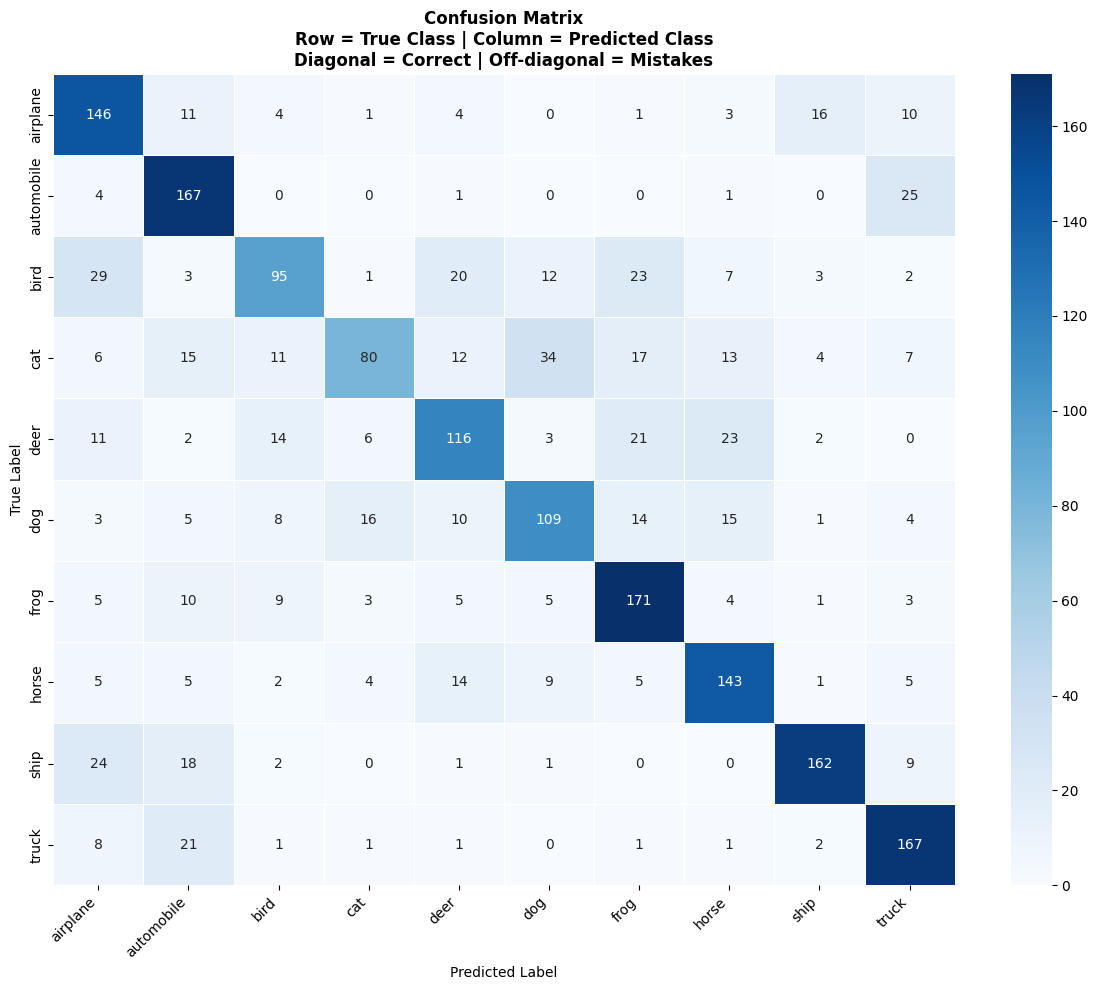

In [31]:
# Confusion Matrix
# Shows exactly which classes the model confuses with each other
# Diagonal = correct predictions (want HIGH)
# Off-diagonal = mistakes (want LOW)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
plt.title(
    'Confusion Matrix\n'
    'Row = True Class | Column = Predicted Class\n'
    'Diagonal = Correct | Off-diagonal = Mistakes',
    fontsize=12, fontweight='bold'
)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plots/08_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()


Observation:<br>
- High numbers on the diagonal = model is correct for that class.
- Cat and dog often confused - they look similar at 32x32 pixels.
- Automobile and truck also confused - both are vehicles.

## **Show Predictions on Real Images**

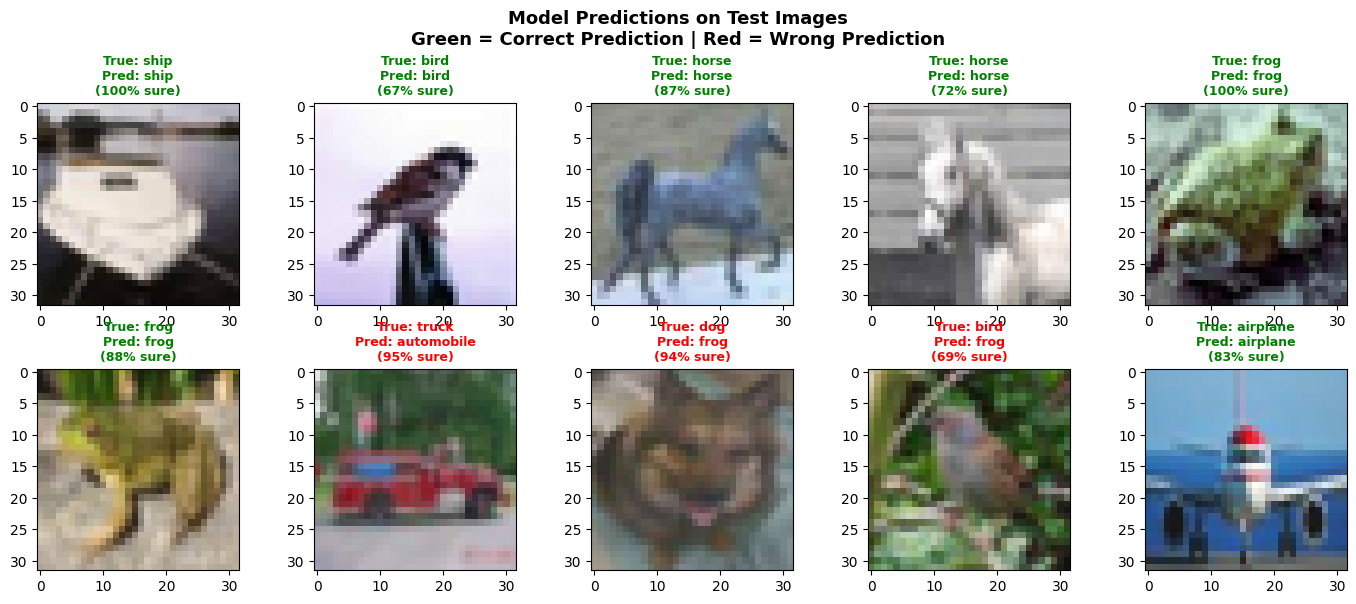

In this sample of 10 images: 7 correct, 3 wrong


In [32]:
# Pick 10 random test images to show
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle(
    'Model Predictions on Test Images\n'
    'Green = Correct Prediction | Red = Wrong Prediction',
    fontsize=13, fontweight='bold'
)

correct_count = 0

for i, idx in enumerate(sample_indices):
    row = i // 5
    col = i % 5

    true_label  = class_names[y_true[idx]]
    pred_label  = class_names[y_pred[idx]]
    confidence  = y_pred_prob[idx][y_pred[idx]] * 100
    is_correct  = (true_label == pred_label)

    if is_correct:
      correct_count += 1

    axes[row, col].imshow(X_test[idx])
    axes[row, col].set_title(
        f'True: {true_label}\nPred: {pred_label}\n({confidence:.0f}% sure)',
        fontsize=9,
        color='green' if is_correct else 'red',
        fontweight='bold'
    )
    axes[row, col].imshow(X_test[idx])

plt.tight_layout()
plt.savefig('predictions.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"In this sample of 10 images: {correct_count} correct, {10-correct_count} wrong")

## **Grad- CAM (Model Explainability)**

In [33]:
# Grad-CAM function — creates a heatmap showing where the model looked
# We use model.input (singular) — works correctly for Sequential models

def make_gradcam(model, image, last_conv_layer_name):
    """
    Creates a heatmap showing where the model looked
    when making its prediction.

    How it works:
    1. Pass the image through the model
    2. Find which parts of the last conv layer activated most
    3. Create a heatmap from those activations
    """
    # Build a model that outputs both the last conv layer and the final prediction
    conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = tf.keras.models.Model(
        inputs  = model.input,   # use model.input (not model.inputs) for Sequential
        outputs = [conv_layer.output, model.output]
    )

    image_array = np.array([image])    # add batch dimension

    # Record gradients while passing image through
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(image_array)
        pred_index  = tf.argmax(predictions[0])
        class_score = predictions[:, pred_index]

    # Get gradients for the predicted class
    gradients    = tape.gradient(class_score, conv_output)
    pooled_grads = tf.reduce_mean(gradients, axis=(0, 1, 2))

    # Weight each feature map by how important it is
    conv_output = conv_output[0]
    heatmap     = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap     = tf.squeeze(heatmap).numpy()

    # Normalise to 0-1 range for display
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() != 0:
        heatmap = heatmap / heatmap.max()

    return heatmap, int(pred_index), float(predictions[0][pred_index])

print("Grad-CAM function ready!")

Grad-CAM function ready!


In [34]:
# Function to show original image + heatmap + overlay side by side

def show_gradcam(model, image, true_label, last_conv_layer):
    heatmap, pred_idx, confidence = make_gradcam(model, image, last_conv_layer)

    # Resize heatmap to match image size (32x32)
    heatmap_resized = np.array(
        tf.image.resize([heatmap[:, :, np.newaxis]], [32, 32])
    ).squeeze()

    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    # Left: original image
    axes[0].imshow(image)
    axes[0].set_title(f'Original\nTrue: {true_label}', fontsize=10)
    axes[0].axis('off')

    # Middle: heatmap only
    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title('Grad-CAM Heatmap\nbright = model focused here', fontsize=10)
    axes[1].axis('off')

    # Right: heatmap overlaid on image
    axes[2].imshow(image)
    axes[2].imshow(heatmap_resized, cmap='jet', alpha=0.5)
    axes[2].set_title(
        f'Overlay\nPred: {class_names[pred_idx]} ({confidence*100:.0f}%)',
        fontsize=10
    )
    axes[2].axis('off')

    plt.suptitle(
        'Grad-CAM: What did the model look at to make this prediction?',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout()
    return fig

print("Display function ready!")

Display function ready!


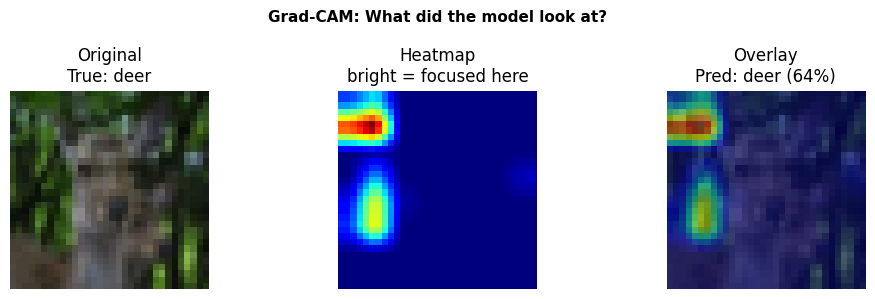

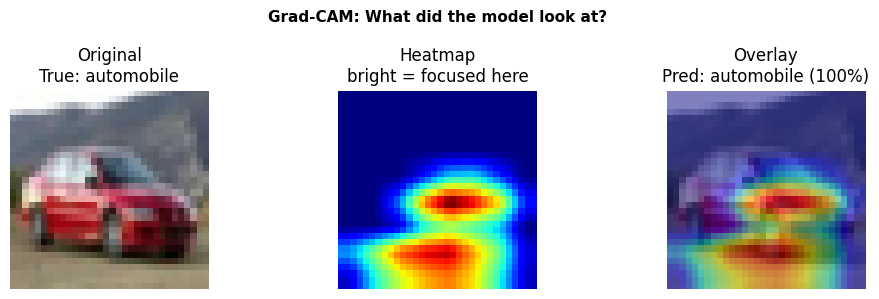

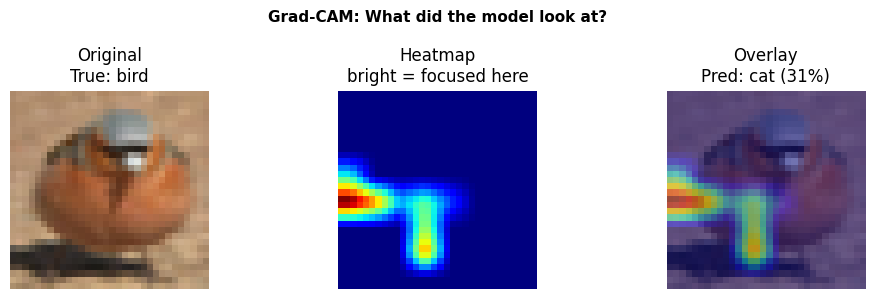

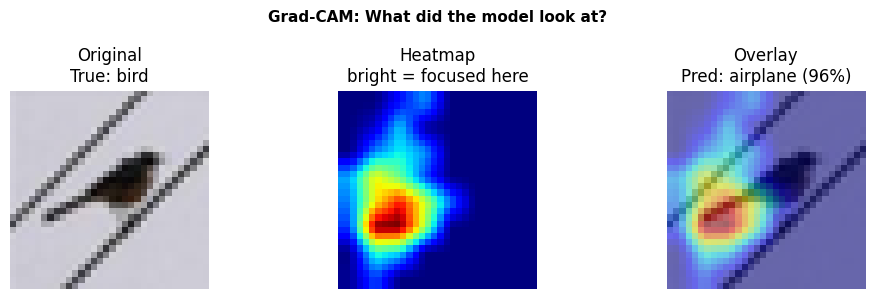

Grad-CAM complete!


In [43]:
# Grad-CAM using manual layer outputs — works with Keras 3
# No model.input needed

np.random.seed(0)

for idx in np.random.choice(len(X_test), 4, replace=False):
    true_lbl = class_names[np.argmax(y_test[idx])]
    image    = X_test[idx]
    img      = tf.cast(np.array([image]), tf.float32)

    # Manually pass image through each layer and record conv output
    last_conv_output = None
    last_conv_name   = None
    x = img

    with tf.GradientTape() as tape:
        tape.watch(x)
        for layer in model.layers:
            x = layer(x)
            if isinstance(layer, tf.keras.layers.Conv2D):
                last_conv_output = x
                last_conv_name   = layer.name
                tape.watch(last_conv_output)

        preds     = x   # final output after all layers
        top_class = tf.argmax(preds[0])
        score     = preds[:, top_class]

    # Calculate heatmap
    grads   = tape.gradient(score, last_conv_output)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = (last_conv_output[0] @ pooled[..., tf.newaxis]).numpy().squeeze()
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()
    heatmap = np.array(tf.image.resize([heatmap[:, :, np.newaxis]], [32, 32])).squeeze()

    pred_label = class_names[int(top_class)]
    confidence = float(preds[0][int(top_class)]) * 100

    # Show result
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    axes[0].imshow(image)
    axes[0].set_title(f'Original\nTrue: {true_lbl}')
    axes[0].axis('off')
    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('Heatmap\nbright = focused here')
    axes[1].axis('off')
    axes[2].imshow(image)
    axes[2].imshow(heatmap, cmap='jet', alpha=0.5)
    axes[2].set_title(f'Overlay\nPred: {pred_label} ({confidence:.0f}%)')
    axes[2].axis('off')
    plt.suptitle('Grad-CAM: What did the model look at?', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'plots/gradcam_{true_lbl}.png', dpi=120, bbox_inches='tight')
    plt.show()

print("Grad-CAM complete!")

## **Download Model for Streamlit App**

In [44]:
# Download the best model to your computer
# Put it in the models/ folder of your project before running the Streamlit app

from google.colab import files
files.download('models/best_model.h5')
print("Model downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model downloaded!


## **FINAL SUMMARY**

In [46]:
print(f"\nDataset         : CIFAR-10")
print(f"Training images : {X_train_final.shape[0]}")
print(f"Test accuracy   : {test_accuracy * 100:.2f}%")
print(f"\nModels trained:")
print(f"  Custom CNN          : {cnn_acc*100:.2f}%")
print(f"  Transfer Learning   : {tl_acc*100:.2f}%")
print(f"\nFiles saved:")
print(f"  models/custom_cnn.h5       <- custom CNN model")
print(f"  models/transfer_model.h5   <- transfer learning model")
print(f"  models/best_model.h5       <- best model (used by Streamlit app)")
print(f"  plots/                     <- all charts and heatmaps")



Dataset         : CIFAR-10
Training images : 8000
Test accuracy   : 67.80%

Models trained:
  Custom CNN          : 66.70%
  Transfer Learning   : 67.80%

Files saved:
  models/custom_cnn.h5       <- custom CNN model
  models/transfer_model.h5   <- transfer learning model
  models/best_model.h5       <- best model (used by Streamlit app)
  plots/                     <- all charts and heatmaps
